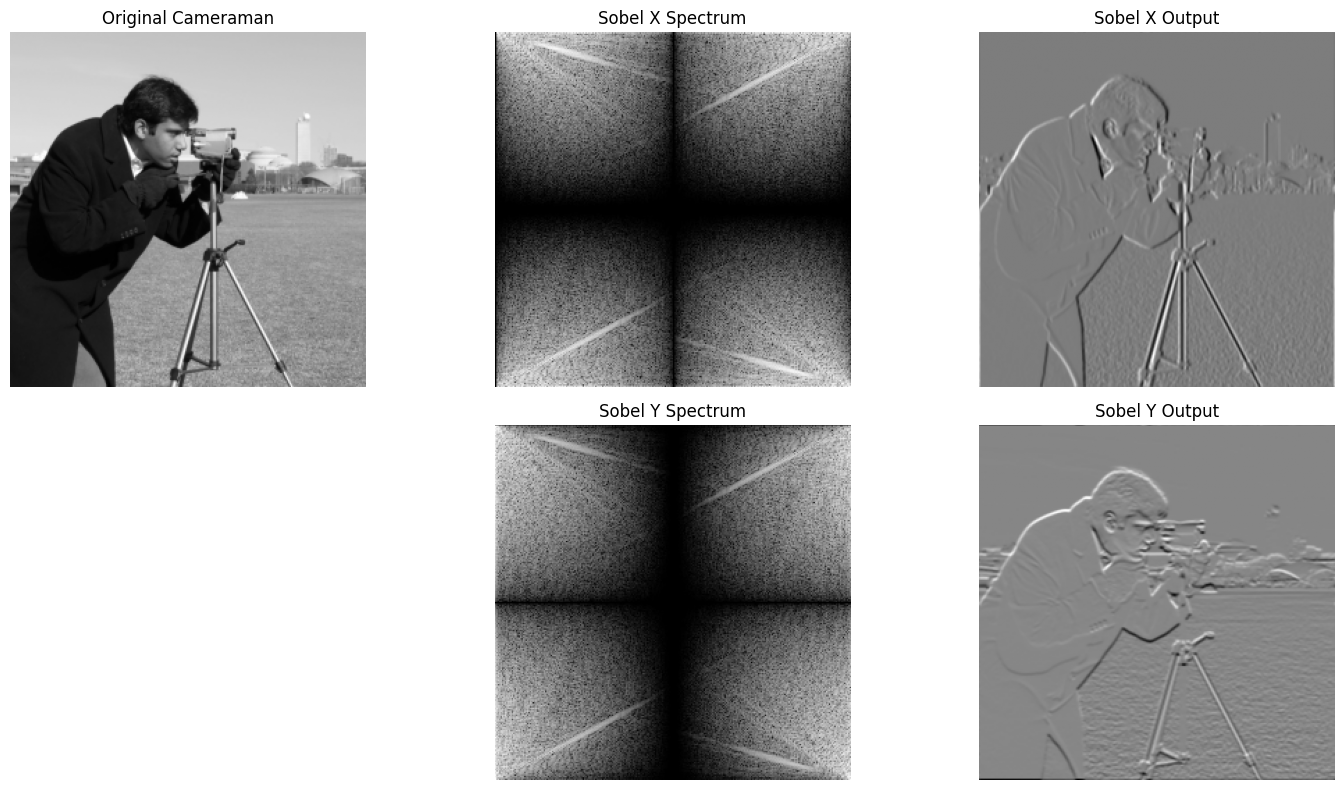

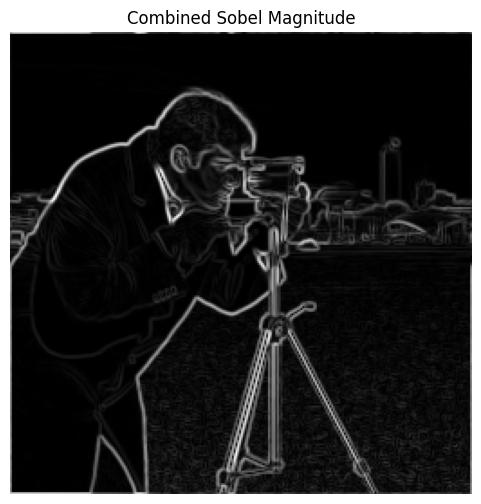

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, ifftshift

# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))  # Resize for faster FFT (optional)

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    
    # Find center coordinates
    cy, cx = ph // 2, pw // 2
    
    # Insert kernel centered at the image center
    padded[cy - kh//2:cy - kh//2 + kh, cx - kw//2:cx - kw//2 + kw] = kernel
    
    return fft2(ifftshift(padded))  # Shift before FFT to place (0,0) at top-left

# Compute FFT of image
F = fft2(image)

# FFT of centered Sobel filters
H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)

# Multiply in the frequency domain
F_sobel_x = F * H_x
F_sobel_y = F * H_y

# Inverse FFT to get spatial results
sobel_x_image = ifft2(F_sobel_x).real
sobel_y_image = ifft2(F_sobel_y).real

# Combine Sobel x and y results
sobel_magnitude = np.sqrt(sobel_x_image**2 + sobel_y_image**2)

# Plot results
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.abs(F_sobel_x)), cmap='gray')
plt.title('Sobel X Spectrum')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(sobel_x_image, cmap='gray')
plt.title('Sobel X Output')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(np.log(1 + np.abs(F_sobel_y)), cmap='gray')
plt.title('Sobel Y Spectrum')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(sobel_y_image, cmap='gray')
plt.title('Sobel Y Output')
plt.axis('off')

plt.tight_layout()
plt.show()

# Plot combined Sobel result
plt.figure(figsize=(6, 6))
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Combined Sobel Magnitude')
plt.axis('off')
plt.show()